In [33]:
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv('/content/Admission_Predict.csv')

In [35]:
df.shape

(400, 9)

- Here, the column names as:
1. GRE Scores ( out of 340 )
2. TOEFL Scores ( out of 120 )
3. University Rating ( out of 5 )
4. Statement of Purpose and Letter of Recommendation Strength ( out of 5 )
5. Undergraduate GPA ( out of 10 )
6. Research Experience ( either 0 or 1 )
7. Chance of Admit ( ranging from 0 to 1)

In [36]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
225,226,296,99,2,2.5,2.5,8.03,0,0.61
224,225,305,105,2,3.0,2.0,8.23,0,0.67
18,19,318,110,3,4.0,3.0,8.80,0,0.63
60,61,309,100,2,3.0,3.0,8.10,0,0.48
254,255,321,114,4,4.0,5.0,9.12,0,0.85


In [37]:
df.drop('Serial No.',axis=1,inplace=True)

In [38]:
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [39]:
x = df.iloc[:, :7].values
y = df.iloc[:, -1].values

In [40]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [41]:
x = sc.fit_transform(x)

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=15)

In [76]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [178]:
model = Sequential()

In [179]:
model.add(Dense(14, activation = 'relu', input_dim = x_train.shape[1] ))
# model.add(Dense(14, activation = 'relu'))
# model.add(Dense(7, activation = 'relu'))
# model.add(Dense(7, activation = 'relu'))
model.add(Dense(1, activation = 'linear')) # whenever we do Regression then set this as Linear

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [180]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [181]:
model.compile(loss = 'mean_squared_error', optimizer = 'Adam')

In [182]:
history = model.fit(x_train, y_train, epochs = 100, batch_size=10, verbose=1, validation_split=0.2)
# to prevent overfitting

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2214 - val_loss: 0.1574
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1797 - val_loss: 0.1288
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1466 - val_loss: 0.1076
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1538 - val_loss: 0.0933
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1041 - val_loss: 0.0770
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0868 - val_loss: 0.0649
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0779 - val_loss: 0.0544
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0639 - val_loss: 0.0445
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0518 - val_loss: 0.0366
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0436 - val_loss: 0.0314
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0372 - val_loss: 0.0260
Epoch 12/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [183]:
y_pred = model.predict(x_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [184]:
from sklearn.metrics import r2_score

In [185]:
r2_score(y_test, y_pred)

0.752836368250051

In [186]:
# call 'history' variable and it returns "loss" & "val_loss", so we plot them side-by-side

In [165]:
history.history

{'loss': [0.32209718227386475,
  0.15834268927574158,
  0.10214090347290039,
  0.08523166924715042,
  0.07280965149402618,
  0.06192236393690109,
  0.053285881876945496,
  0.045891787856817245,
  0.03950638324022293,
  0.03450976684689522,
  0.029992420226335526,
  0.02633834257721901,
  0.02328260987997055,
  0.02077844738960266,
  0.018676115199923515,
  0.01690213568508625,
  0.015432383865118027,
  0.014235126785933971,
  0.013339723460376263,
  0.012565821409225464,
  0.011878438293933868,
  0.011251426301896572,
  0.010613751597702503,
  0.01018627267330885,
  0.009746845811605453,
  0.009272029623389244,
  0.008936995640397072,
  0.008731106296181679,
  0.008358024060726166,
  0.008136296644806862,
  0.00785058829933405,
  0.007606620900332928,
  0.0073623815551400185,
  0.007197586353868246,
  0.007084205746650696,
  0.006877990905195475,
  0.006721385754644871,
  0.006595467682927847,
  0.006540823262184858,
  0.006358087062835693,
  0.006188000086694956,
  0.00611078273504972

In [187]:
import matplotlib.pyplot as plt

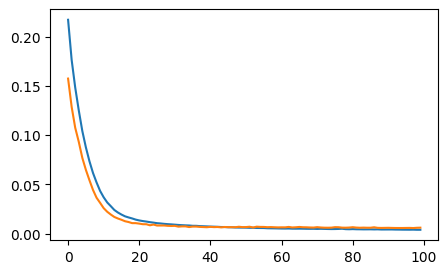

In [188]:
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss']);
